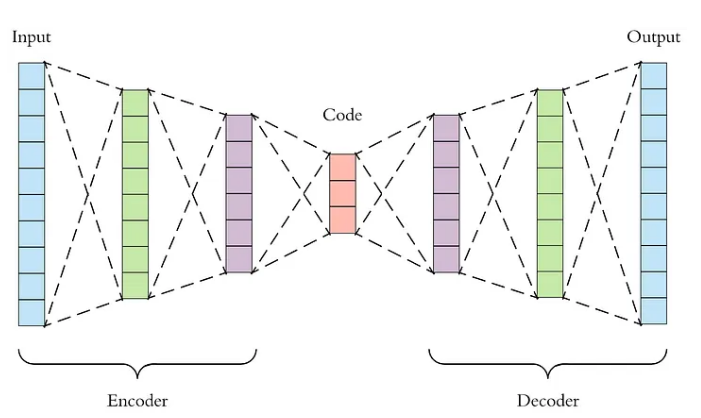

In [4]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
transform = transforms.Compose(
    [
        transforms.ToTensor()
    ]
)

In [7]:
train_data = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_data = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)

In [8]:
batch_size = 64

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)

In [9]:
print(len(train_data))
print(len(train_loader))
print(len(train_data) / batch_size)

60000
938
937.5


In [10]:
class AutoEncoder(nn.Module):

    def __init__(self):
        super(AutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(), # 28 * 28 -> 784
            nn.Linear(in_features=28*28, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(in_features=64, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=28*28),
            nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1,28,28))
        )



    def forward(self, x):

        encoded = self.encoder(x)

        decoded = self.decoder(encoded)

        return decoded

In [11]:
class EarlyStopping:

    def __init__(self, patience = 5, min_delta = 0.001):
        
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def __call__(self, loss):
        
        if self.best_loss is None or loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.counter = 0
        else:
            self.counter +=1
        

        if self.counter >= self.patience:
            return True
        
        return False

In [12]:
epochs = 25
learning_rate = 0.001

In [13]:
model = AutoEncoder().to(device=device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=3, min_delta=0.001)

In [14]:
def training(model, train_loader, optimizer, criterion, early_stopping, epochs):
    model.train()

    prev_loss = None

    for epoch in range(epochs):
        total_loss = 0
        for inputs, _ in train_loader:
            inputs = inputs.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() # total los for 1 epoch



        avg_loss = total_loss/len(train_loader)

        if prev_loss is not None:
            loss_diff = prev_loss - avg_loss
            
            diff_text = f" | Difference Loss: {loss_diff:.6f}   min_delta: 0.001 "
        else:
            diff_text = " | Difference Loss : ---   min_delta: 0.001 " 

        print(f"Epoch: {epoch + 1} / {epochs},   Loss: {avg_loss:.6f}")
        print(f"{diff_text}")

        prev_loss = avg_loss

        if early_stopping(avg_loss):
            print(f"Early stopping at epoch {epoch + 1}")
            break

In [15]:
training(model=model, train_loader=train_loader, optimizer=optimizer, criterion=criterion, early_stopping=early_stopping, epochs=epochs)

Epoch: 1 / 25,   Loss: 0.032854
 | Difference Loss : ---   min_delta: 0.001 
Epoch: 2 / 25,   Loss: 0.019790
 | Difference Loss: 0.013064   min_delta: 0.001 
Epoch: 3 / 25,   Loss: 0.016819
 | Difference Loss: 0.002971   min_delta: 0.001 
Epoch: 4 / 25,   Loss: 0.014991
 | Difference Loss: 0.001828   min_delta: 0.001 
Epoch: 5 / 25,   Loss: 0.013905
 | Difference Loss: 0.001086   min_delta: 0.001 
Epoch: 6 / 25,   Loss: 0.013125
 | Difference Loss: 0.000780   min_delta: 0.001 
Epoch: 7 / 25,   Loss: 0.012548
 | Difference Loss: 0.000577   min_delta: 0.001 
Epoch: 8 / 25,   Loss: 0.012036
 | Difference Loss: 0.000512   min_delta: 0.001 
Epoch: 9 / 25,   Loss: 0.011640
 | Difference Loss: 0.000397   min_delta: 0.001 
Epoch: 10 / 25,   Loss: 0.011278
 | Difference Loss: 0.000362   min_delta: 0.001 
Epoch: 11 / 25,   Loss: 0.010973
 | Difference Loss: 0.000305   min_delta: 0.001 
Epoch: 12 / 25,   Loss: 0.010704
 | Difference Loss: 0.000270   min_delta: 0.001 
Epoch: 13 / 25,   Loss: 0.010

In [42]:
from scipy.ndimage import gaussian_filter

def compute_ssim(img1, img2, sigma=1.5):
    c1 = (0.01*255)**2
    c2 = (0.03*255)**2

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    mu1 = gaussian_filter(img1, sigma=sigma)
    mu2 = gaussian_filter(img2, sigma=sigma)

    mu1_sq = mu1**2
    mu2_sq = mu2**2
    mu1_mu2 = mu1 * mu2

    sigma1_sq = gaussian_filter(img1**2, sigma) - mu1_sq
    sigma2_sq = gaussian_filter(img2**2, sigma) - mu2_sq
    sigma12 = gaussian_filter(img1*img2, sigma) - mu1_mu2

    ssim_map = ((2*mu1_mu2 + c1) * ( 2* sigma12 + c2))/((mu1_sq + mu2 **2 + c1) * (sigma1_sq + sigma2_sq + c2))

    return ssim_map.mean()

In [43]:
def evaluate(model, test_loader, n_images = 10):

    model.eval()

    with torch.no_grad():
        for batch in test_loader:
            inputs, _ = batch
            inputs = inputs.to(device)
            outputs = model(inputs)
            break # 1 batch 

    inputs = inputs.cpu().numpy()
    outputs = outputs.detach().cpu().numpy()

    fig, axes = plt.subplots(2, n_images, figsize = (n_images, 3))

    ssim_scores = []

    for i in range (n_images):

        img1 = np.squeeze(inputs[i])
        img2 = np.squeeze(outputs[i])

        ssim_score = compute_ssim(img1, img2)
        ssim_scores.append(ssim_score)


        axes[0,i].imshow(img1, cmap="gray")
        axes[0,i].axis("off")
        axes[1,i].imshow(img2, cmap="gray")
        axes[1,i].axis("off")

    axes[0,0].set_title("Original")
    axes[1,0].set_title("Decoded")
    plt.show()


    avg_ssim = np.mean(ssim_scores)
    print(f"Average ssim score : {avg_ssim}")

                

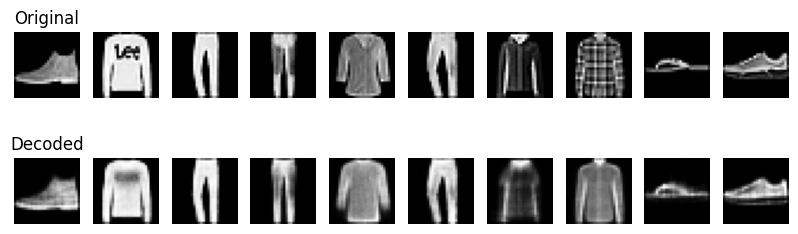

Average ssim score : 0.9997549300626357


In [44]:
evaluate(model, test_loader, 10)